# 🛒 E-commerce Product Recommendation System
## Notebook 2: Feature Engineering

**Goal:** Build three groups of features that will power our XGBoost recommendation model.

| Feature Group | What it captures | Features |
|---|---|---|
| **User (RFM)** | Who is this customer? | Recency, Frequency, Monetary |
| **Product** | How popular is this product? | TotalUnitsSold, UniqueBuyers, AvgTransactionValue |
| **User-Product** | Does this customer like this category? | CategoryAffinity, CategoryCount, HasBoughtProduct |

---
### Notebook Outline
1. Load & prep data
2. User Features — RFM
3. Product Features
4. Category Engineering — data-driven keyword taxonomy
5. User-Product Interaction Features
6. Summary

---
## 1. Load & Prep Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load cleaned data from Notebook 01
df_clean = pd.read_csv('../data/df_clean.csv')

# Fix dtypes lost during CSV save
# InvoiceDate: CSV saves as string → must re-parse
# CustomerID: CSV saves as int → must re-cast to string (avoid '13085.0' issues)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID']  = df_clean['CustomerID'].astype(str)

# TotalPrice — revenue per transaction row
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"✅ Loaded: {df_clean.shape[0]:,} rows | {df_clean['CustomerID'].nunique():,} customers | {df_clean['Description'].nunique():,} products")
df_clean.head()

✅ Loaded: 270,848 rows | 3,936 customers | 3,779 products


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,day_of_week,hour,TotalPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,12,2,8,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,2,8,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,12,2,8,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,2,8,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,2,8,20.34


---
## 2. User Features — RFM

RFM is a classic customer segmentation framework used across e-commerce, banking, and retail.
Each dimension captures a different aspect of customer behaviour:

| Dimension | Question | Calculation |
|---|---|---|
| **Recency** | How recently did they buy? | Days since last purchase |
| **Frequency** | How often do they buy? | Total transaction count |
| **Monetary** | How much do they spend? | Sum of UnitPrice × Quantity |

⚠️ **Why not use today's date for Recency?**  
Our data ends Dec 2011. Using today's date (2025) makes every customer equally stale — relative differences disappear.  
We use `max(InvoiceDate) + 1 day` as reference so recent buyers have low recency, old buyers have high recency.

In [2]:
# ── RFM Aggregation ────────────────────────────────────────────────────
# One row per customer — summarises their entire purchase history
rfm = df_clean.groupby('CustomerID').agg(
    LastPurchaseDate = ('InvoiceDate', 'max'),    # R: most recent purchase date
    Frequency        = ('CustomerID', 'count'),   # F: total transactions
    Monetary         = ('TotalPrice', 'sum')      # M: total spend (£)
).reset_index()

# Recency = days between last purchase and reference date
# Low recency = bought recently = good signal
reference_date   = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm['Recency']   = (reference_date - rfm['LastPurchaseDate']).dt.days
rfm['CustomerID'] = rfm['CustomerID'].astype(str)

print(f"RFM table shape: {rfm.shape}  (one row per customer)")
print(f"Reference date for Recency: {reference_date.date()}")
print()
print(rfm[['CustomerID','Recency','Frequency','Monetary']].describe().round(2))

RFM table shape: (3936, 5)  (one row per customer)
Reference date for Recency: 2011-12-10

       Recency  Frequency   Monetary
count  3936.00    3936.00    3936.00
mean     91.78      68.81    1507.27
std      97.83      70.53    4511.11
min       1.00       5.00      36.56
25%      19.00      19.00     317.19
50%      52.00      42.00     674.60
75%     138.00      94.00    1540.84
max     374.00     349.00  194550.79


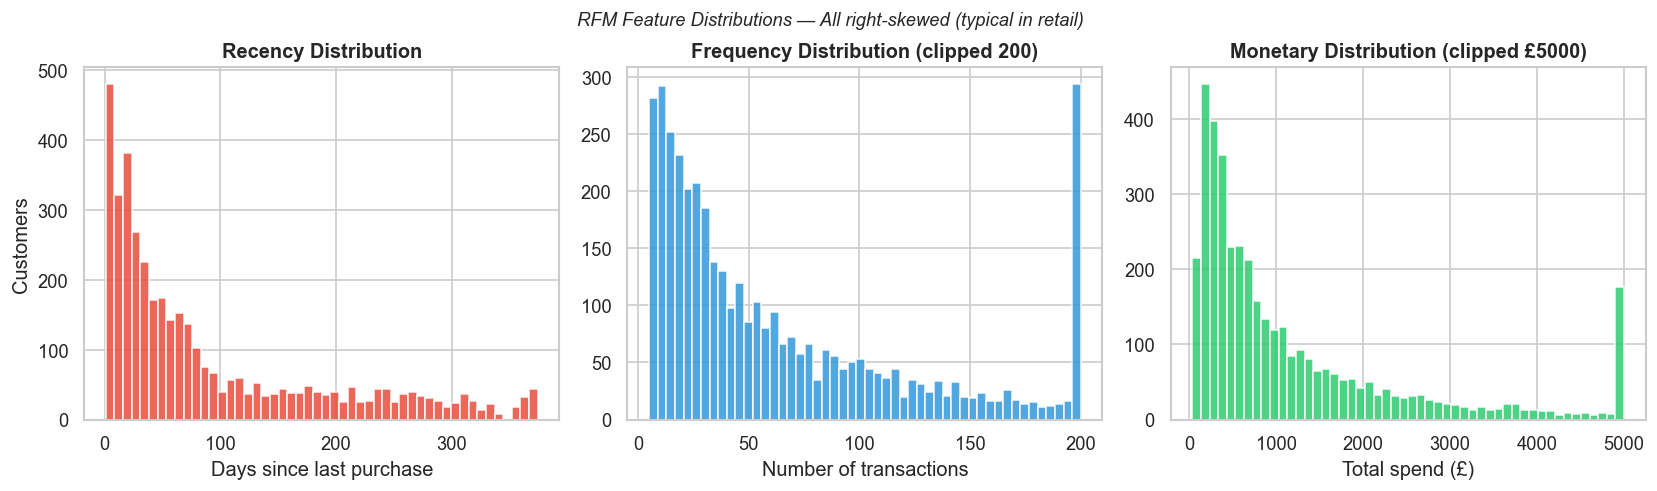

In [3]:
# ── RFM Distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rfm['Recency'], bins=50, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Customers')

axes[1].hist(rfm['Frequency'].clip(0, 200), bins=50, color='#3498DB', edgecolor='white', alpha=0.85)
axes[1].set_title('Frequency Distribution (clipped 200)', fontweight='bold')
axes[1].set_xlabel('Number of transactions')

axes[2].hist(rfm['Monetary'].clip(0, 5000), bins=50, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[2].set_title('Monetary Distribution (clipped £5000)', fontweight='bold')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('RFM Feature Distributions — All right-skewed (typical in retail)', 
             fontsize=11, fontstyle='italic', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', bbox_inches='tight')
plt.show()

---
## 3. Product Features

Product-level features capture how popular and valuable each product is globally (across all customers).  
These features answer: *"Is this a popular product that many people buy?"*

| Feature | Calculation | Signal |
|---|---|---|
| `TotalUnitsSold` | sum(Quantity) per product | Overall volume |
| `UniqueBuyers` | nunique(CustomerID) per product | Breadth of appeal — bought by many different people |
| `AvgTransactionValue` | mean(TotalPrice) per product | Price tier — premium vs budget |

⚠️ **Why UniqueBuyers and not just TotalUnitsSold?**  
A product bought 500 times by 1 wholesale customer ≠ a product bought 500 times by 500 different customers.  
UniqueBuyers captures genuine breadth of appeal.

In [4]:
# ── Product-level aggregation ──────────────────────────────────────────
# One row per product — summarises its purchase history across all customers
products = df_clean.groupby('Description').agg(
    TotalUnitsSold      = ('Quantity',     'sum'),      # total units sold globally
    UniqueBuyers        = ('CustomerID',   'nunique'),  # distinct customers who bought it
    AvgTransactionValue = ('TotalPrice',   'mean')      # average spend per transaction
).reset_index()

print(f"Product table shape: {products.shape}  (one row per product)")
print()
print("Top 10 most bought products:")
print(products.nlargest(10, 'TotalUnitsSold')[['Description','TotalUnitsSold','UniqueBuyers']].to_string(index=False))

Product table shape: (3779, 4)  (one row per product)

Top 10 most bought products:
                       Description  TotalUnitsSold  UniqueBuyers
 WORLD WAR 2 GLIDERS ASSTD DESIGNS           46238           268
           JUMBO BAG RED RETROSPOT           33406           528
WHITE HANGING HEART T-LIGHT HOLDER           28815           750
     ASSORTED COLOUR BIRD ORNAMENT           27041           604
         PACK OF 12 LONDON TISSUES           23680           157
                    POPCORN HOLDER           23550           239
   PACK OF 72 RETROSPOT CAKE CASES           21566           529
PACK OF 60 PINK PAISLEY CAKE CASES           20046           330
            MINI PAINT SET VINTAGE           18796           188
   VICTORIAN GLASS HANGING T-LIGHT           17758           348


---
## 4. Category Engineering

We don't have an explicit category column — only free-text `Description`.  
We build a proxy category using a **data-driven keyword approach:**

1. Extract all words from descriptions + compute frequencies
2. Filter out noise words (colours, sizes, stop words, pattern names)
3. Build keyword → category mapping from meaningful words
4. Scan each description word-by-word — first matching keyword wins

**Why not use the last word?** → Last word is often a colour (`RED`, `WHITE`) or size (`LARGE`, `SMALL`) — not a category.  
**Why not BERT?** → Overkill for this project. Keyword heuristics achieve 86% coverage. In production: use a proper product taxonomy.

**Result: 86.4% of products assigned to 23 meaningful categories (13.6% OTHER)**

In [5]:
# ── Step 1: Remove punctuation ─────────────────────────────────────────
# Punctuation like '-' creates compound tokens e.g. 'T-LIGHT' → after removal → 'T LIGHT'
# This improves word matching significantly
df_clean['Description'] = df_clean['Description'].apply(
    lambda x: re.sub(r'[^\w\s]', ' ', str(x))
)

# ── Step 2: Word frequency analysis ────────────────────────────────────
# Extract all words to understand natural product vocabulary
noise_words = {
    'OF', 'IN', 'AND', 'WITH', 'TO', 'THE', 'A',           # stop words
    'RED', 'PINK', 'WHITE', 'BLUE', 'GREEN', 'CREAM',       # colours
    'BLACK', 'YELLOW', 'GREY', 'ORANGE', 'IVORY',
    'LARGE', 'SMALL', 'JUMBO', 'MINI',                      # sizes
    '3', '6', '12', '24', '1', '2',                         # numbers
    'RETROSPOT', 'POLKADOT', 'VINTAGE', 'SPACEBOY',         # patterns/styles
    'REGENCY', 'DESIGN', 'ASSORTED', 'COLOUR'
}

all_words = df_clean['Description'].str.split().explode()
word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.most_common(100), columns=['Word', 'Count'])
meaningful = word_freq_df[~word_freq_df['Word'].isin(noise_words)]

print("Top 30 meaningful words (after removing noise):")
print(meaningful.head(30).to_string(index=False))

Top 30 meaningful words (after removing noise):
      Word  Count
       SET  32495
       BAG  23694
     HEART  20395
 CHRISTMAS  13797
       BOX  11922
      CAKE  10895
     METAL  10175
     LIGHT   9976
         T   9323
   HANGING   9013
    HOLDER   8887
     LUNCH   8887
      PACK   7992
      SIGN   7912
     PAPER   7482
    WOODEN   7018
      CARD   6526
     GLASS   6462
     CASES   6244
       TEA   6195
    BOTTLE   6100
DECORATION   5868
       HOT   5638
     WATER   5346
      HOME   5329
         4   5240
         S   5239
    PANTRY   5230
       TIN   5111
   DOORMAT   4834


In [6]:
# ── Step 3: Keyword → Category mapping ────────────────────────────────
# Built from word frequency analysis above
# Each keyword maps to a business-meaningful category
category_map = {
    # Kitchen & Food
    'TEA': 'KITCHEN',    'BOTTLE': 'KITCHEN',  'GLASS': 'KITCHEN',
    'CAKE': 'KITCHEN',   'LUNCH': 'KITCHEN',   'PANTRY': 'KITCHEN',
    'CERAMIC': 'KITCHEN','TIN': 'KITCHEN',     'CUTLERY': 'KITCHEN',
    'APRON': 'KITCHEN',  'KITCHEN': 'KITCHEN', 'DISH': 'KITCHEN',
    'TRAY': 'KITCHEN',

    # Mugs
    'COFFEE': 'MUGS',    'MUGS': 'MUGS',       'MUG': 'MUGS',

    # Storage & Organisation
    'BOX': 'STORAGE',    'CASES': 'STORAGE',   'HOLDER': 'STORAGE',
    'WRAP': 'STORAGE',   'DRAWER': 'STORAGE',  'WOOD': 'STORAGE',

    # Bags & Accessories
    'BAG': 'BAGS',       'BACKPACK': 'BAGS',   'PURSE': 'BAGS',
    'RIBBON': 'ACCESSORIES', 'RIBBONS': 'ACCESSORIES',

    # Bundles — separate category: distinct buying behaviour (higher spend, lower frequency)
    'SET': 'BUNDLES',    'PACK': 'BUNDLES',

    # Home & Decor
    'HOME': 'HOME_DECOR',      'SIGN': 'HOME_DECOR',    'HANGING': 'HOME_DECOR',
    'DECORATION': 'HOME_DECOR','DOORMAT': 'HOME_DECOR', 'CLOCK': 'HOME_DECOR',
    'WOODEN': 'HOME_DECOR',    'METAL': 'HOME_DECOR',   'HANGER': 'HOME_DECOR',
    'PAPER': 'HOME_DECOR',     'ORNAMENT': 'HOME_DECOR','BIN': 'HOME_DECOR',
    'VINTAGE': 'HOME_DECOR',   'PICTURE': 'HOME_DECOR', 'DOORSIGN': 'HOME_DECOR',
    'CROCHET': 'HOME_DECOR',   'POT': 'HOME_DECOR',     'ART': 'HOME_DECOR',
    'EMBROIDERED': 'HOME_DECOR','GLOBE': 'HOME_DECOR',  'DOORSTOP': 'HOME_DECOR',
    'CANDLES': 'HOME_DECOR',

    # Lighting
    'CANDLE': 'LIGHTING', 'LIGHT': 'LIGHTING',  'LIGHTS': 'LIGHTING',
    'LANTERN': 'LIGHTING','NIGHTLIGHT': 'LIGHTING', 'NIGHT': 'LIGHTING',

    # Gifts & Occasions
    'GIFT': 'GIFTS',  'HEART': 'GIFTS',  'FRAME': 'GIFTS',
    'FELTCRAFT': 'GIFTS', 'ANTIQUE': 'GIFTS',

    # Seasonal
    'CHRISTMAS': 'SEASONAL', 'HOT': 'SEASONAL',     'WARMER': 'SEASONAL',
    'KNITTED': 'SEASONAL',   'COAT': 'SEASONAL',    'UMBRELLA': 'SEASONAL',
    'EDWARDIAN': 'SEASONAL', 'STAR': 'SEASONAL',

    # Cards
    'CARD': 'CARDS',

    # Party & Picnic
    'PARTY': 'PARTY & PICNIC', 'PICNIC': 'PARTY & PICNIC',
    'HONEYCOMB': 'PARTY & PICNIC', 'DISCO': 'PARTY & PICNIC',

    # Toys & Games
    'PLAYHOUSE': 'TOYS', 'DOLL': 'TOYS',   'BUNNIES': 'TOYS',
    'TOY': 'TOYS',  'CHILDRENS': 'TOYS',   'DINOSAUR': 'TOYS',
    'BUTTERFILES': 'TOYS', 'PIGGY': 'TOYS',
    'PUZZLE': 'GAMES', 'JIGSAW': 'GAMES',  'GAME': 'GAMES',
    'KNITTING': 'GAMES', 'WORD': 'GAMES',  'PIRATE': 'GAMES',

    # School & Stationery
    'SCISSOR': 'SCHOOL', 'BOOKS': 'SCHOOL', 'BOOK': 'SCHOOL',
    'PENCILS': 'SCHOOL', 'PEN': 'SCHOOL',   'PENS': 'SCHOOL',
    'CHALKBOARD': 'SCHOOL',

    # Bathroom
    'BATH': 'BATHROOM',   'MIRROR': 'BATHROOM',

    # Makeup & Beauty
    'LIP': 'MAKEUP',      'CREAM': 'MAKEUP',

    # Gardening
    'GARDEN': 'GARDENING', 'GARDENERS': 'GARDENING',

    # Souvenir
    'MAGNETS': 'SOUVENIR', 'POSTAGE': 'SOUVENIR', 'LONDON': 'SOUVENIR',

    # Chocolates
    'CHOCOLATE': 'CHOCOLATES',
}

# ── Step 4: Assign category — scan ALL words, first match wins ─────────
# Scanning all words (not just last word) avoids colour/size false matches
def assign_category(desc):
    words = str(desc).split()
    for word in words:
        if word in category_map:
            return category_map[word]
    return 'OTHER'

df_clean['Category'] = df_clean['Description'].apply(assign_category)

print(df_clean['Category'].value_counts())
print(f"\nOTHER %: {(df_clean['Category'] == 'OTHER').mean()*100:.1f}%")

HOME_DECOR        52436
OTHER             36620
BUNDLES           35711
KITCHEN           33477
GIFTS             22443
STORAGE           15900
BAGS              14755
SEASONAL          14693
LIGHTING           5910
TOYS               5306
SCHOOL             5297
CARDS              5111
PARTY & PICNIC     4395
MAKEUP             3414
MUGS               3001
GARDENING          2948
ACCESSORIES        2688
SOUVENIR           2153
CHOCOLATES         1842
GAMES              1628
BATHROOM           1120
Name: Category, dtype: int64

OTHER %: 13.5%


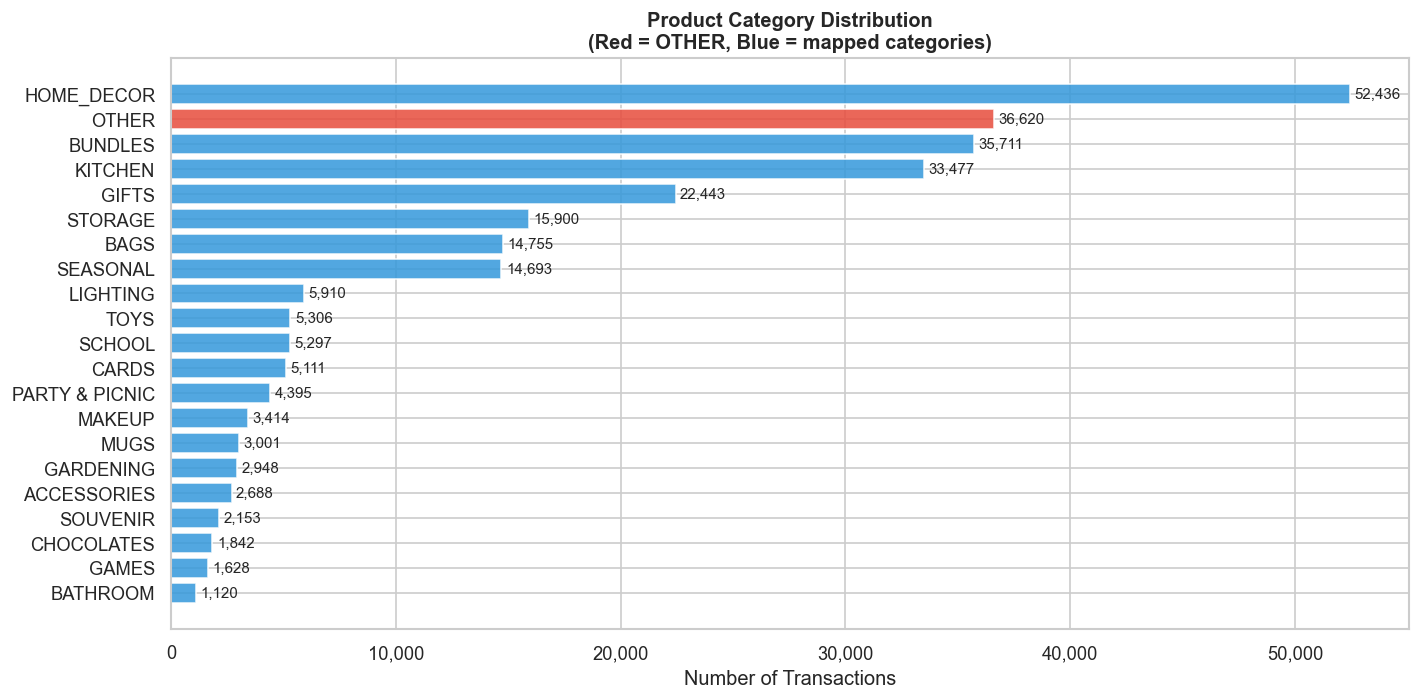


✅ 20 meaningful categories created
Coverage: 86.5% of transactions assigned to a category


In [7]:
# ── Category Distribution Visualisation ───────────────────────────────
cat_counts = df_clean['Category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#E74C3C' if c == 'OTHER' else '#3498DB' for c in cat_counts.index]
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1], edgecolor='white', alpha=0.85)

for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Product Category Distribution\n(Red = OTHER, Blue = mapped categories)', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Transactions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/category_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n✅ {len(cat_counts)-1} meaningful categories created")
print(f"Coverage: {100 - (df_clean['Category'] == 'OTHER').mean()*100:.1f}% of transactions assigned to a category")

In [8]:
# ── Add Category to Products table ────────────────────────────────────
desc_to_category = df_clean[['Description', 'Category']].drop_duplicates(subset='Description')
products = products.merge(desc_to_category, on='Description', how='left')

print(f"Products table shape: {products.shape}")
products.head()

Products table shape: (3779, 5)


,Description,TotalUnitsSold,UniqueBuyers,AvgTransactionValue,Category
0,10 COLOUR SPACEBOY PEN,4516,148,20.648000,SCHOOL
1,12 COLOURED PARTY BALLOONS,1525,79,10.325521,PARTY & PICNIC
2,12 DAISY PEGS IN WOOD BOX,217,29,10.230000,STORAGE
3,12 EGG HOUSE PAINTED WOOD,60,31,22.500000,STORAGE
4,12 HANGING EGGS HAND PAINTED,42,7,8.736000,HOME_DECOR


---
## 5. User-Product Interaction Features

These are the **most powerful features** — they directly model the relationship between a specific customer and a specific product/category.

| Feature | Calculation | Signal |
|---|---|---|
| `CategoryAffinity` | purchases in category / total purchases | How much does this customer like this category? (0–1) |
| `CustomerCategoryCount` | count of purchases in this category | Raw volume of category purchases |
| `HasBoughtProduct` | 1 if ever purchased, else 0 | Direct purchase history signal |
| `TimesBought` | count of purchases of this product | Repeat purchase signal |

**CategoryAffinity example:**  
Customer bought 10 products → 7 in KITCHEN → `CategoryAffinity(KITCHEN) = 0.70`  
If we're considering recommending a KITCHEN product → 70% affinity = strong positive signal

⚠️ `HasBoughtProduct = 0` will appear in **negative samples** (next notebook).  
This table only contains products each customer HAS bought — all values are 1 here.

In [9]:
# ── Category Affinity per Customer ────────────────────────────────────
# Step 1: Total purchases per customer
customer_total = (df_clean
    .groupby('CustomerID')['Description']
    .count()
    .reset_index()
    .rename(columns={'Description': 'TotalPurchases'}))

# Step 2: Purchases per customer per category
customer_category = (df_clean
    .groupby(['CustomerID', 'Category'])['Description']
    .count()
    .reset_index()
    .rename(columns={'Description': 'CategoryCount'}))

# Step 3: Merge and compute affinity score
# Affinity = what fraction of this customer's purchases are in this category?
customer_category = customer_category.merge(customer_total, on='CustomerID')
customer_category['CategoryAffinity'] = (
    customer_category['CategoryCount'] / customer_category['TotalPurchases']
)

print(f"Customer-Category affinity table shape: {customer_category.shape}")
print(f"Average categories per customer: {customer_category.groupby('CustomerID').size().mean():.1f}")
print()
print("Sample — Customer 12347's category affinities:")
sample = customer_category[customer_category['CustomerID']=='12347'].sort_values('CategoryAffinity', ascending=False)
print(sample[['Category','CategoryCount','CategoryAffinity']].to_string(index=False))

Customer-Category affinity table shape: (39619, 5)
Average categories per customer: 10.1

Sample — Customer 12347's category affinities:
  Category  CategoryCount  CategoryAffinity
     OTHER             35          0.192308
HOME_DECOR             31          0.170330
      BAGS             24          0.131868
   KITCHEN             24          0.131868
   BUNDLES             18          0.098901
     GIFTS             14          0.076923
  LIGHTING             14          0.076923
   STORAGE             10          0.054945
    SCHOOL              5          0.027473
  SEASONAL              3          0.016484
  BATHROOM              1          0.005495
CHOCOLATES              1          0.005495
     GAMES              1          0.005495
    MAKEUP              1          0.005495


In [10]:
# ── Has Bought Product (Purchase History) ─────────────────────────────
# For each (CustomerID, Product) pair — how many times has this customer bought this product?
# HasBoughtProduct = 1 for all rows here (only purchased products exist)
# HasBoughtProduct = 0 will be assigned to NEGATIVE SAMPLES in Notebook 03
customer_products = (df_clean
    .groupby(['CustomerID', 'Description'])['Quantity']
    .count()
    .reset_index()
    .rename(columns={'Quantity': 'TimesBought'}))

customer_products['HasBoughtProduct'] = 1  # all rows here are positive (purchased)

print(f"Customer-Product history table shape: {customer_products.shape}")
print(f"This covers {customer_products.shape[0]:,} unique (customer, product) pairs out of {df_clean['CustomerID'].nunique() * df_clean['Description'].nunique():,} possible")
print()
customer_products.head()

Customer-Product history table shape: (209114, 4)
This covers 209,114 unique (customer, product) pairs out of 14,866,272 possible



,CustomerID,Description,TimesBought,HasBoughtProduct
0,12347,3D DOG PICTURE PLAYING CARDS,5,1
1,12347,3D SHEET OF CAT STICKERS,1,1
2,12347,3D SHEET OF DOG STICKERS,1,1
3,12347,60 TEATIME FAIRY CAKE CASES,3,1
4,12347,72 SWEETHEART FAIRY CAKE CASES,3,1


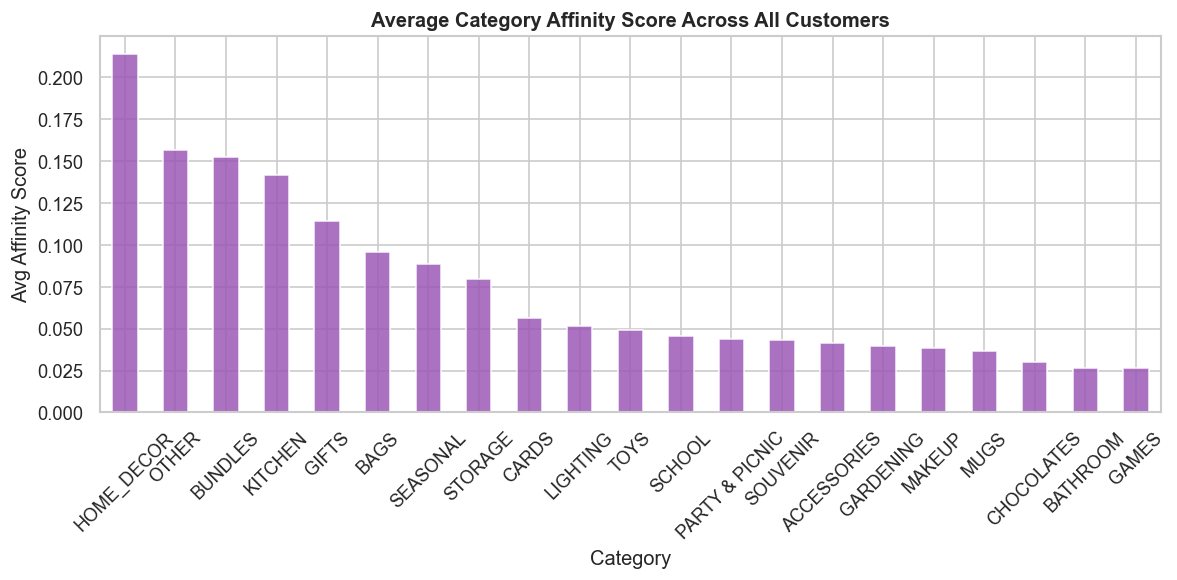

In [11]:
# ── Top Category Affinities Visualisation ─────────────────────────────
# Shows which categories dominate customer preferences
top_affinity = (customer_category
    .groupby('Category')['CategoryAffinity']
    .mean()
    .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
top_affinity.plot(kind='bar', ax=ax, color='#9B59B6', edgecolor='white', alpha=0.85)
ax.set_title('Average Category Affinity Score Across All Customers', fontweight='bold', fontsize=12)
ax.set_xlabel('Category')
ax.set_ylabel('Avg Affinity Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/category_affinity.png', bbox_inches='tight')
plt.show()

---
## 6. Save All Feature Tables

In [12]:
# ── Save all feature tables for Notebook 03 ───────────────────────────
rfm.to_csv('../data/rfm.csv', index=False)
products.to_csv('../data/products.csv', index=False)
customer_category.to_csv('../data/customer_category.csv', index=False)
customer_products.to_csv('../data/customer_products.csv', index=False)
df_clean.to_csv('../data/df_clean.csv', index=False)   # re-save with Category column

print("✅ Saved:")
print("   data/rfm.csv               → user-level RFM features")
print("   data/products.csv          → product-level features + category")
print("   data/customer_category.csv → category affinity per customer")
print("   data/customer_products.csv → purchase history per (customer, product)")
print("   data/df_clean.csv          → updated with Category column")

✅ Saved:
   data/rfm.csv               → user-level RFM features
   data/products.csv          → product-level features + category
   data/customer_category.csv → category affinity per customer
   data/customer_products.csv → purchase history per (customer, product)
   data/df_clean.csv          → updated with Category column


In [13]:
# ── Feature Engineering Summary ───────────────────────────────────────
print("=" * 60)
print("       FEATURE ENGINEERING — FINAL SUMMARY")
print("=" * 60)
print()
print("GROUP 1 — USER FEATURES (RFM)")
print(f"  Table shape:    {rfm.shape}")
print( "  Features:       Recency, Frequency, Monetary")
print( "  Key decision:   Reference date = max(InvoiceDate)+1 day")
print( "                  Avoids stale recency from using today's date")
print()
print("GROUP 2 — PRODUCT FEATURES")
print(f"  Table shape:    {products.shape}")
print( "  Features:       TotalUnitsSold, UniqueBuyers, AvgTransactionValue, Category")
print( "  Key decision:   UniqueBuyers not just TotalSold — captures genuine appeal")
print()
print("GROUP 3 — USER-PRODUCT INTERACTION FEATURES")
print(f"  Affinity table: {customer_category.shape}")
print(f"  History table:  {customer_products.shape}")
print( "  Features:       CategoryAffinity, CategoryCount, HasBoughtProduct, TimesBought")
print( "  Key decision:   HasBoughtProduct=0 assigned during negative sampling (Nb03)")
print()
print("CATEGORY ENGINEERING")
print(f"  Method:         Data-driven keyword scan (all words, first match wins)")
print(f"  Categories:     {df_clean['Category'].nunique()} categories")
print(f"  Coverage:       {100 - (df_clean['Category'] == 'OTHER').mean()*100:.1f}% mapped | {(df_clean['Category'] == 'OTHER').mean()*100:.1f}% OTHER")
print( "  Prod note:      In production → use proper product taxonomy or classifier")
print()
print("=" * 60)
print("NEXT → Notebook 03: Train/Test Split + Negative Sampling")
print("=" * 60)

       FEATURE ENGINEERING — FINAL SUMMARY

GROUP 1 — USER FEATURES (RFM)
  Table shape:    (3936, 5)
  Features:       Recency, Frequency, Monetary
  Key decision:   Reference date = max(InvoiceDate)+1 day
                  Avoids stale recency from using today's date

GROUP 2 — PRODUCT FEATURES
  Table shape:    (3779, 5)
  Features:       TotalUnitsSold, UniqueBuyers, AvgTransactionValue, Category
  Key decision:   UniqueBuyers not just TotalSold — captures genuine appeal

GROUP 3 — USER-PRODUCT INTERACTION FEATURES
  Affinity table: (39619, 5)
  History table:  (209114, 4)
  Features:       CategoryAffinity, CategoryCount, HasBoughtProduct, TimesBought
  Key decision:   HasBoughtProduct=0 assigned during negative sampling (Nb03)

CATEGORY ENGINEERING
  Method:         Data-driven keyword scan (all words, first match wins)
  Categories:     21 categories
  Coverage:       86.5% mapped | 13.5% OTHER
  Prod note:      In production → use proper product taxonomy or classifier

NEXT → N